# SADAR Finance - Behavior Spike Detection Model

Notebook ini dibuat sebagai versi mandiri untuk training ulang model behavior dari awal, termasuk saat dijalankan di Google Colab.

Nama model yang dipakai di notebook ini adalah **Behavior Spike Detection Model**, bukan overspending model murni. Model ini mendeteksi transaksi yang terlihat sebagai `spike` atau pola pengeluaran tidak biasa. Output model dapat dipakai oleh fitur alert untuk membantu mencegah overspending, tetapi model ini tidak memprediksi budget bulanan secara langsung.

Model yang dibandingkan:
- **Tabular DNN / MLP** sebagai baseline deep learning.
- **Deep & Cross Network** sebagai model utama untuk menangkap interaksi fitur transaksi.

Target quest:
- TensorFlow Functional API.
- Custom Layer, Custom Loss Function, dan Custom Callback.
- Custom training/evaluation loop dengan `tf.GradientTape`.
- TensorBoard logs.
- Export `.keras` dan SavedModel.
- Inference sederhana.
- Accuracy minimal 85% dan MAE maksimal 0,02.

## 1. Setup Dataset

Jika menjalankan di Google Colab, upload file `data_modelling.csv` saat diminta. Jika menjalankan dari repo lokal, notebook akan otomatis mencari dataset di `ai/dataset/data_modelling.csv`.

In [3]:
import sys
import subprocess

def ensure_package(package):
    try:
        __import__(package.split('==')[0].replace('-', '_'))
    except Exception:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

for package in ['tensorflow', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn']:
    ensure_package(package)

print('Environment ready')

z:\Dicoding\sadar-finance\ai\.venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Environment ready


In [ ]:
from pathlib import Path
import json
import math
import shutil
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

sns.set_theme(style='whitegrid')
tf.random.set_seed(42)
np.random.seed(42)

try:
    from IPython.display import display
except Exception:
    display = print

# try:
#     from google.colab import files
#     IN_COLAB = True
# except Exception:
#     IN_COLAB = False

ROOT = Path.cwd()
COLAB_DATASET = Path('/content/data_modelling.csv')

DATASET_CANDIDATES = [
    ROOT / 'dataset' / 'data_modelling.csv',
    ROOT / 'ai' / 'dataset' / 'data_modelling.csv',
    ROOT.parent / 'ai' / 'dataset' / 'data_modelling.csv',
]
DATASET_PATH = next((path for path in DATASET_CANDIDATES if path.exists()), None)

if DATASET_PATH is None and IN_COLAB:
    if not COLAB_DATASET.exists():
        print('Upload data_modelling.csv')
        uploaded = files.upload()
    DATASET_PATH = COLAB_DATASET

if DATASET_PATH is None:
    raise FileNotFoundError('data_modelling.csv tidak ditemukan. Jalankan notebook dari root repo atau folder ai.')

if IN_COLAB:
    OUTPUT_DIR = Path('/content/behavior_outputs')
    LOG_DIR = Path('/content/behavior_logs')
elif (ROOT / 'dataset' / 'data_modelling.csv').exists():
    OUTPUT_DIR = ROOT / 'models'
    LOG_DIR = ROOT / 'logs' / 'behavior_spike'
elif (ROOT / 'ai').exists():
    OUTPUT_DIR = ROOT / 'ai' / 'models'
    LOG_DIR = ROOT / 'ai' / 'logs' / 'behavior_spike'
else:
    OUTPUT_DIR = ROOT / 'behavior_outputs'
    LOG_DIR = ROOT / 'behavior_logs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print('IN_COLAB:', IN_COLAB)
print('Dataset:', DATASET_PATH)
print('Output dir:', OUTPUT_DIR)
print('Log dir:', LOG_DIR)

IN_COLAB: False
Dataset: z:\Dicoding\sadar-finance\ai\dataset\data_modelling.csv
Output dir: z:\Dicoding\sadar-finance\ai\models
Log dir: z:\Dicoding\sadar-finance\ai\logs\behavior_spike


## 2. Load Dataset dan EDA

Target model adalah `spike`. Fitur `spending_level` dan `log_amount` sengaja tidak dipakai agar model tidak terlalu bergantung pada fitur turunan yang terlalu dekat dengan nominal.

In [5]:
df = pd.read_csv(DATASET_PATH, parse_dates=['date'])
print('Shape:', df.shape)
display(df.head())
display(df.isna().sum().to_frame('missing'))

Shape: (9579, 20)


,transaction_id,user_id,date,merchant,amount,category_detail,category_primary,payment_method,payment_media,day_of_week,month,is_weekend,day,week,time_of_day,spending_level,log_amount,rolling_7d_spending,transaction_count,spike
0,TXN004191,USR051,2022-12-27 00:18:13,PLN Mobile,334000.0,utilities,Needs,Transfer,DANA,Tuesday,12,False,27,52,Malam,high,12.718899,NaN,1,False
1,TXN000058,USR015,2022-12-27 04:47:18,Pluang,442500.0,investment,Investment,Transfer,DANA,Tuesday,12,False,27,52,Malam,high,13.000198,NaN,1,False
2,TXN006945,USR062,2022-12-27 07:48:27,Giant,180000.0,groceries,Needs,Debit,BCA,Tuesday,12,False,27,52,Pagi,medium,12.100718,NaN,1,False
3,TXN007877,USR003,2022-12-27 09:12:38,WeTV,71000.0,entertainment,Wants,Cash,Cash,Tuesday,12,False,27,52,Pagi,medium,11.170449,NaN,1,False
4,TXN007697,USR036,2022-12-27 11:59:49,Blue Bird,51000.0,transport,Needs,QRIS,BCA,Tuesday,12,False,27,52,Pagi,medium,10.839601,NaN,1,False


,missing
transaction_id,0
user_id,0
date,0
merchant,0
amount,0
category_detail,0
category_primary,0
payment_method,0
payment_media,0
day_of_week,0


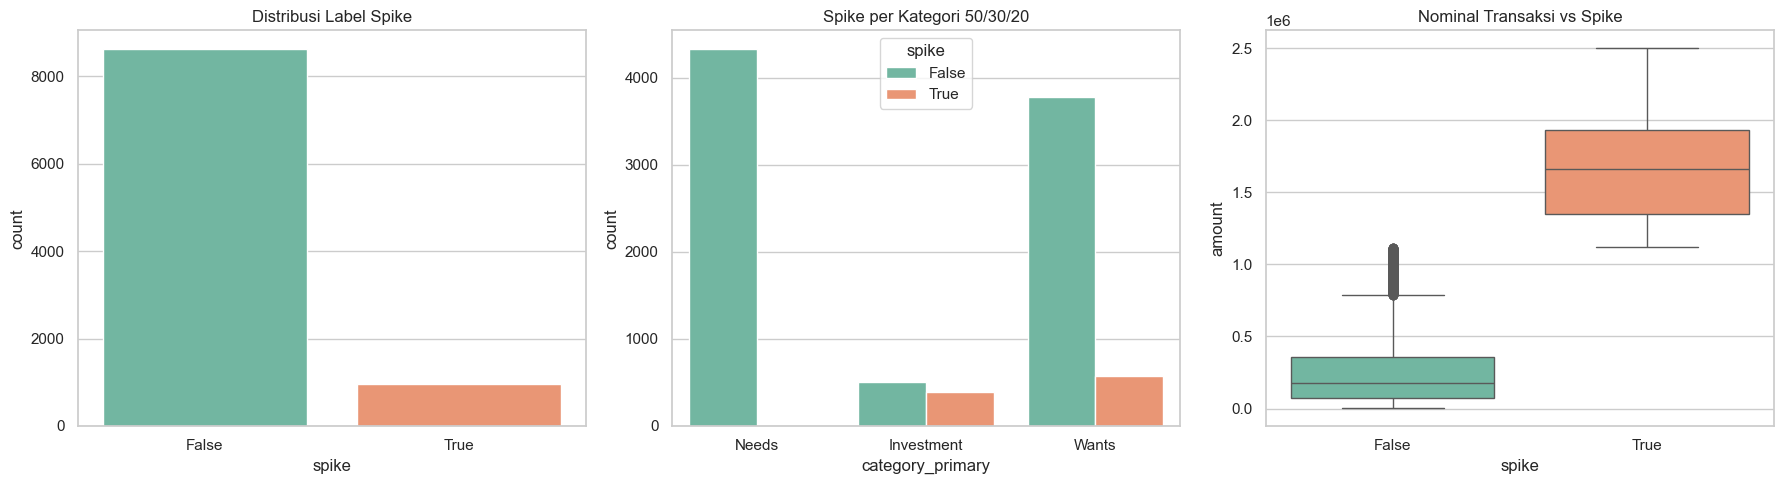

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='spike', ax=axes[0], hue='spike', palette='Set2', legend=False)
axes[0].set_title('Distribusi Label Spike')

sns.countplot(data=df, x='category_primary', hue='spike', ax=axes[1], palette='Set2')
axes[1].set_title('Spike per Kategori 50/30/20')

sns.boxplot(data=df, x='spike', y='amount', ax=axes[2], hue='spike', palette='Set2', legend=False)
axes[2].set_title('Nominal Transaksi vs Spike')

plt.tight_layout()
plt.show()

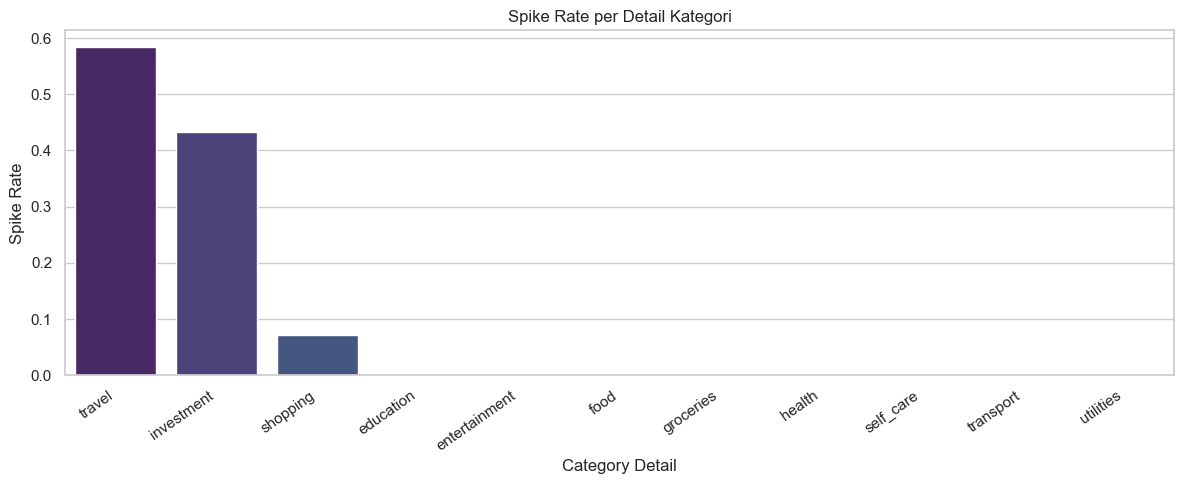

,category_detail,spike_rate
0,travel,0.584400
1,investment,0.433185
2,shopping,0.072354
3,education,0.000000
4,entertainment,0.000000
5,food,0.000000
6,groceries,0.000000
7,health,0.000000
8,self_care,0.000000
9,transport,0.000000


In [7]:
spike_rate = df.groupby('category_detail')['spike'].mean().sort_values(ascending=False).reset_index(name='spike_rate')

plt.figure(figsize=(12, 5))
sns.barplot(data=spike_rate, x='category_detail', y='spike_rate', hue='category_detail', palette='viridis', legend=False)
plt.title('Spike Rate per Detail Kategori')
plt.xlabel('Category Detail')
plt.ylabel('Spike Rate')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

display(spike_rate)

## 3. Feature Set dan Preprocessing

Split data memakai urutan waktu 70/15/15 agar evaluasi lebih realistis dibanding random split.

In [8]:
NUMERIC_FEATURES = [
    'amount', 'month', 'day', 'week', 'is_weekend', 'rolling_7d_spending', 'transaction_count'
]

CATEGORICAL_FEATURES = [
    'merchant', 'category_detail', 'category_primary', 'payment_method', 'payment_media', 'day_of_week', 'time_of_day'
]

TARGET_COLUMN = 'spike'
MODEL_VERSION = 'behavior-spike-v1'

def prepare_dataframe(data):
    data = data.sort_values('date').reset_index(drop=True).copy()
    data['is_weekend'] = data['is_weekend'].astype(float)
    data['rolling_7d_spending'] = data['rolling_7d_spending'].fillna(data['amount'])
    data[TARGET_COLUMN] = data[TARGET_COLUMN].astype(float)
    for column in CATEGORICAL_FEATURES:
        data[column] = data[column].fillna('unknown').astype(str)
    for column in NUMERIC_FEATURES:
        data[column] = pd.to_numeric(data[column], errors='coerce').fillna(0).astype('float32')
    return data

df_model = prepare_dataframe(df)
n = len(df_model)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_model.iloc[:train_end].copy()
val_df = df_model.iloc[train_end:val_end].copy()
test_df = df_model.iloc[val_end:].copy()

print(len(train_df), len(val_df), len(test_df))
print('Train date range:', train_df['date'].min(), train_df['date'].max())
print('Test date range:', test_df['date'].min(), test_df['date'].max())

6705 1437 1437
Train date range: 2022-12-27 00:18:13 2024-05-26 17:53:00
Test date range: 2024-09-11 16:20:03 2024-12-31 23:28:44


In [9]:
def frame_to_dataset(data, batch_size=128, shuffle=False):
    features = {}
    for column in NUMERIC_FEATURES:
        features[column] = data[column].astype('float32').to_numpy()
    for column in CATEGORICAL_FEATURES:
        features[column] = data[column].astype(str).to_numpy()
    labels = data[TARGET_COLUMN].astype('float32').to_numpy().reshape(-1, 1)
    ds = tf.data.Dataset.from_tensor_slices((features, labels))
    if shuffle:
        ds = ds.shuffle(len(data), seed=42, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = frame_to_dataset(train_df, shuffle=True)
val_ds = frame_to_dataset(val_df)
test_ds = frame_to_dataset(test_df)

vocabularies = {column: sorted(train_df[column].astype(str).unique().tolist()) for column in CATEGORICAL_FEATURES}
numeric_stats = {
    column: {'mean': float(train_df[column].mean()), 'variance': float(max(train_df[column].var(), 1e-6))}
    for column in NUMERIC_FEATURES
}

print('Vocab sizes:', {k: len(v) for k, v in vocabularies.items()})

Vocab sizes: {'merchant': 187, 'category_detail': 11, 'category_primary': 3, 'payment_method': 5, 'payment_media': 16, 'day_of_week': 7, 'time_of_day': 4}


## 4. Custom Layer, Custom Loss, dan Custom Callback

Bagian ini memenuhi main quest komponen kustom lanjutan.

In [10]:
@tf.keras.utils.register_keras_serializable(package='SadarFinance')
class CrossFeatureLayer(tf.keras.layers.Layer):
    def __init__(self, num_layers=2, **kwargs):
        super().__init__(**kwargs)
        self.num_layers = num_layers
        self.kernels = []
        self.biases = []

    def build(self, input_shape):
        dim = int(input_shape[-1])
        for i in range(self.num_layers):
            self.kernels.append(self.add_weight(name=f'cross_kernel_{i}', shape=(dim, 1), initializer='glorot_uniform'))
            self.biases.append(self.add_weight(name=f'cross_bias_{i}', shape=(dim,), initializer='zeros'))
        super().build(input_shape)

    def call(self, inputs):
        x0 = inputs
        x = inputs
        for kernel, bias in zip(self.kernels, self.biases):
            xw = tf.matmul(x, kernel)
            x = x0 * xw + bias + x
        return x

    def get_config(self):
        config = super().get_config()
        config.update({'num_layers': self.num_layers})
        return config


@tf.keras.utils.register_keras_serializable(package='SadarFinance')
class WeightedBinaryCrossentropy(tf.keras.losses.Loss):
    def __init__(self, positive_weight=1.0, name='weighted_binary_crossentropy'):
        super().__init__(name=name)
        self.positive_weight = positive_weight

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), 1e-7, 1.0 - 1e-7)
        positive_loss = -self.positive_weight * y_true * tf.math.log(y_pred)
        negative_loss = -(1.0 - y_true) * tf.math.log(1.0 - y_pred)
        return tf.reduce_mean(positive_loss + negative_loss)

    def get_config(self):
        return {'positive_weight': self.positive_weight, 'name': self.name}


class QuestMetricCallback:
    def __init__(self, min_accuracy=0.85, max_mae=0.02):
        self.min_accuracy = min_accuracy
        self.max_mae = max_mae
        self.best_score = -np.inf
        self.best_weights = None
        self.best_epoch = 0

    def on_epoch_end(self, epoch, model, metrics):
        quest_passed = metrics['accuracy'] >= self.min_accuracy and metrics['mae'] <= self.max_mae
        score = metrics['accuracy'] - metrics['mae'] + metrics.get('recall', 0.0) * 0.1
        if quest_passed and score > self.best_score:
            self.best_score = score
            self.best_epoch = epoch
            self.best_weights = model.get_weights()
        return quest_passed

    def restore_best(self, model):
        if self.best_weights is not None:
            model.set_weights(self.best_weights)

## 5. Arsitektur Model: MLP vs Deep & Cross Network

Keduanya memakai TensorFlow Functional API. Deep & Cross Network memakai custom layer `CrossFeatureLayer`.

In [11]:
def dense_stack(inputs, units, prefix):
    x = inputs
    for i, unit_count in enumerate(units):
        x = tf.keras.layers.Dense(unit_count, activation='relu', name=f'{prefix}_dense_{i}')(x)
        x = tf.keras.layers.BatchNormalization(name=f'{prefix}_bn_{i}')(x)
        x = tf.keras.layers.Dropout(0.15, name=f'{prefix}_dropout_{i}')(x)
    return x


def build_behavior_model(model_name):
    inputs = {}
    encoded_features = []

    for column in NUMERIC_FEATURES:
        feature_input = tf.keras.Input(shape=(1,), name=column, dtype=tf.float32)
        normalizer = tf.keras.layers.Normalization(
            mean=[numeric_stats[column]['mean']],
            variance=[numeric_stats[column]['variance']],
            name=f'{column}_normalization',
        )
        inputs[column] = feature_input
        encoded_features.append(normalizer(feature_input))

    for column in CATEGORICAL_FEATURES:
        feature_input = tf.keras.Input(shape=(1,), name=column, dtype=tf.string)
        lookup = tf.keras.layers.StringLookup(vocabulary=vocabularies[column], mask_token=None, num_oov_indices=1, name=f'{column}_lookup')
        vocab_size = len(vocabularies[column]) + 1
        embedding_dim = min(16, max(3, int(round(math.sqrt(vocab_size)))))
        x = lookup(feature_input)
        x = tf.keras.layers.Embedding(vocab_size + 1, embedding_dim, name=f'{column}_embedding')(x)
        x = tf.keras.layers.Flatten(name=f'{column}_flatten')(x)
        inputs[column] = feature_input
        encoded_features.append(x)

    feature_vector = tf.keras.layers.Concatenate(name='feature_vector')(encoded_features)

    if model_name == 'deep_cross':
        cross = CrossFeatureLayer(num_layers=2, name='cross_feature_layer')(feature_vector)
        deep = dense_stack(feature_vector, [128, 64], 'deep_cross_deep')
        x = tf.keras.layers.Concatenate(name='deep_cross_concat')([cross, deep])
        x = tf.keras.layers.Dense(64, activation='relu', name='deep_cross_head')(x)
    elif model_name == 'mlp':
        x = dense_stack(feature_vector, [128, 64, 32], 'mlp')
    else:
        raise ValueError(model_name)

    x = tf.keras.layers.Dropout(0.20, name=f'{model_name}_head_dropout')(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid', name='spike_probability')(x)
    return tf.keras.Model(inputs=inputs, outputs=output, name=f'behavior_{model_name}')


mlp_preview = build_behavior_model('mlp')
deep_cross_preview = build_behavior_model('deep_cross')
print(mlp_preview.name, deep_cross_preview.name)


behavior_mlp behavior_deep_cross


## 6. Custom Training Loop dengan tf.GradientTape

Cell ini melatih kedua model dari awal. Untuk demo cepat, `EPOCHS` bisa dibuat 10-20. Untuk hasil lebih stabil, gunakan 20 epoch seperti implementasi repo.

In [12]:
def collect_predictions(model, dataset):
    labels = []
    probabilities = []
    for features, batch_labels in dataset:
        probabilities.append(model(features, training=False).numpy().reshape(-1))
        labels.append(batch_labels.numpy().reshape(-1).astype('int32'))
    return np.concatenate(labels), np.concatenate(probabilities)


def evaluate_model(model, dataset, threshold=0.5):
    y_true, y_prob = collect_predictions(model, dataset)
    y_pred = (y_prob >= threshold).astype('int32')
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    accuracy = (tp + tn) / max(len(y_true), 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-7)
    mae = float(np.mean(np.abs(y_true.astype('float32') - y_prob.astype('float32'))))
    return {'accuracy': accuracy, 'mae': mae, 'precision': precision, 'recall': recall, 'f1': f1, 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}


def train_with_gradient_tape(model, model_name, epochs=20, learning_rate=0.001):
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    loss_fn = WeightedBinaryCrossentropy(positive_weight=1.0)
    callback = QuestMetricCallback()
    writer = tf.summary.create_file_writer(str(LOG_DIR / model_name))
    history = []

    for epoch in range(1, epochs + 1):
        train_losses = []
        for features, labels in train_ds:
            with tf.GradientTape() as tape:
                predictions = model(features, training=True)
                loss = loss_fn(labels, predictions)
                loss += sum(model.losses)
            gradients = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))
            train_losses.append(float(loss.numpy()))

        val_metrics = evaluate_model(model, val_ds)
        row = {'epoch': epoch, 'model': model_name, 'train_loss': float(np.mean(train_losses)), **val_metrics}
        history.append(row)

        with writer.as_default():
            tf.summary.scalar('loss/train', row['train_loss'], step=epoch)
            for key, value in val_metrics.items():
                tf.summary.scalar(f'validation/{key}', value, step=epoch)

        callback.on_epoch_end(epoch, model, val_metrics)
        print(f"{model_name} epoch {epoch:02d} | loss={row['train_loss']:.4f} | val_acc={row['accuracy']:.4f} | val_mae={row['mae']:.4f}")

    writer.close()
    callback.restore_best(model)
    return model, pd.DataFrame(history), evaluate_model(model, test_ds)


EPOCHS = 20
trained_models = {}
histories = []
test_metrics = {}

for model_name in ['mlp', 'deep_cross']:
    print('\nTraining', model_name)
    model = build_behavior_model(model_name)
    model, history_df, metrics = train_with_gradient_tape(model, model_name, epochs=EPOCHS)
    trained_models[model_name] = model
    histories.append(history_df)
    test_metrics[model_name] = metrics

history_df = pd.concat(histories, ignore_index=True)
metrics_df = pd.DataFrame(test_metrics).T.reset_index().rename(columns={'index': 'model'})
display(metrics_df)


Training mlp
mlp epoch 01 | loss=0.4873 | val_acc=0.9673 | val_mae=0.3029
mlp epoch 02 | loss=0.2532 | val_acc=0.9436 | val_mae=0.1769
mlp epoch 03 | loss=0.1472 | val_acc=0.9492 | val_mae=0.1110
mlp epoch 04 | loss=0.0912 | val_acc=0.9436 | val_mae=0.0877
mlp epoch 05 | loss=0.0713 | val_acc=0.9624 | val_mae=0.0595
mlp epoch 06 | loss=0.0538 | val_acc=0.9687 | val_mae=0.0455
mlp epoch 07 | loss=0.0415 | val_acc=0.9722 | val_mae=0.0389
mlp epoch 08 | loss=0.0311 | val_acc=0.9958 | val_mae=0.0173
mlp epoch 09 | loss=0.0335 | val_acc=0.9875 | val_mae=0.0200
mlp epoch 10 | loss=0.0284 | val_acc=0.9937 | val_mae=0.0128
mlp epoch 11 | loss=0.0244 | val_acc=0.9944 | val_mae=0.0112
mlp epoch 12 | loss=0.0270 | val_acc=0.9930 | val_mae=0.0110
mlp epoch 13 | loss=0.0272 | val_acc=0.9958 | val_mae=0.0089
mlp epoch 14 | loss=0.0259 | val_acc=0.9951 | val_mae=0.0088
mlp epoch 15 | loss=0.0189 | val_acc=0.9937 | val_mae=0.0089
mlp epoch 16 | loss=0.0205 | val_acc=0.9958 | val_mae=0.0077
mlp epoch 

,model,accuracy,mae,precision,recall,f1,tp,tn,fp,fn
0,mlp,0.991649,0.011008,0.973333,0.948052,0.960526,146.0,1279.0,4.0,8.0
1,deep_cross,0.987474,0.014717,0.914634,0.974026,0.943396,150.0,1269.0,14.0,4.0


## 7. Visualisasi Training dan Evaluasi

Akurasi dan MAE dibandingkan dengan threshold quest.

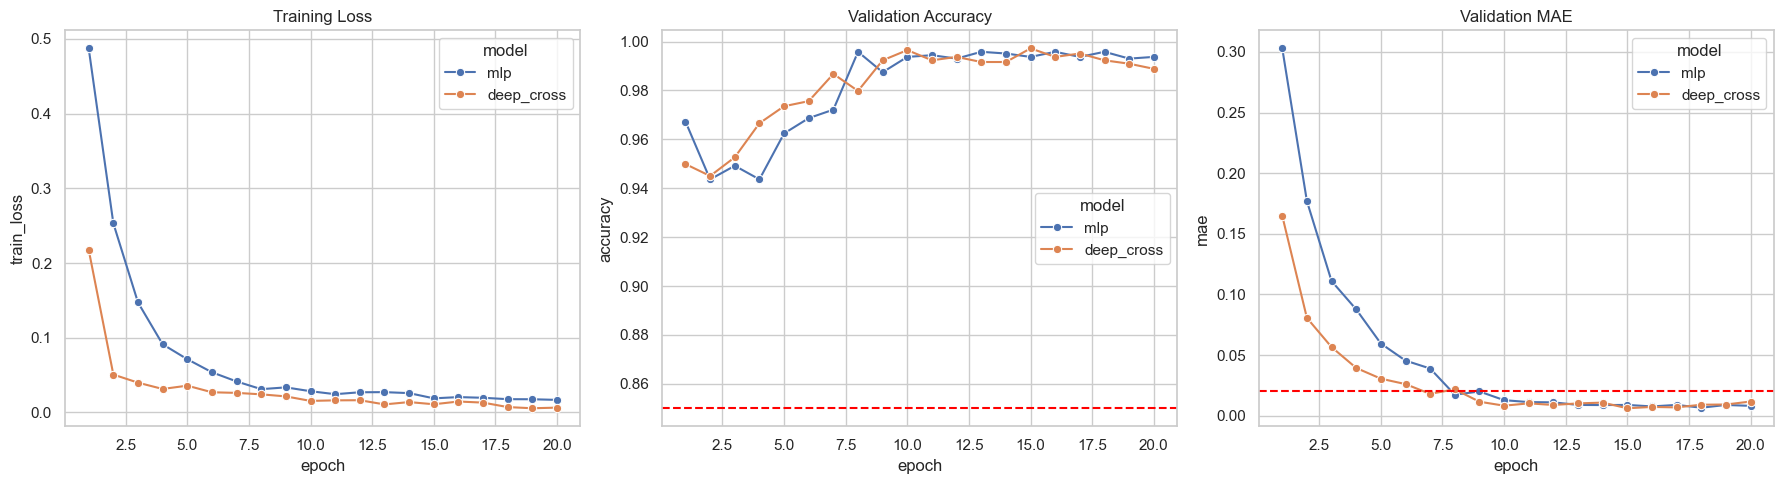

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=history_df, x='epoch', y='train_loss', hue='model', marker='o', ax=axes[0])
axes[0].set_title('Training Loss')

sns.lineplot(data=history_df, x='epoch', y='accuracy', hue='model', marker='o', ax=axes[1])
axes[1].axhline(0.85, color='red', linestyle='--', label='Minimum 85%')
axes[1].set_title('Validation Accuracy')

sns.lineplot(data=history_df, x='epoch', y='mae', hue='model', marker='o', ax=axes[2])
axes[2].axhline(0.02, color='red', linestyle='--', label='Maximum 0.02')
axes[2].set_title('Validation MAE')

plt.tight_layout()
plt.show()

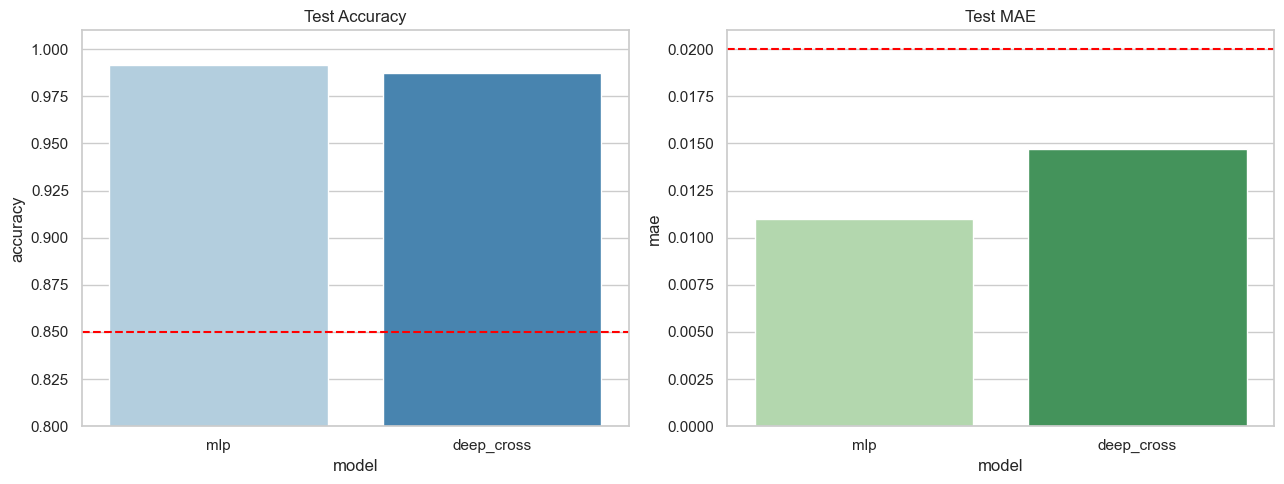

,model,accuracy,mae,precision,recall,f1,tp,tn,fp,fn
0,mlp,0.991649,0.011008,0.973333,0.948052,0.960526,146.0,1279.0,4.0,8.0
1,deep_cross,0.987474,0.014717,0.914634,0.974026,0.943396,150.0,1269.0,14.0,4.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=metrics_df, x='model', y='accuracy', hue='model', palette='Blues', legend=False, ax=axes[0])
axes[0].axhline(0.85, color='red', linestyle='--')
axes[0].set_ylim(0.80, 1.01)
axes[0].set_title('Test Accuracy')

sns.barplot(data=metrics_df, x='model', y='mae', hue='model', palette='Greens', legend=False, ax=axes[1])
axes[1].axhline(0.02, color='red', linestyle='--')
axes[1].set_title('Test MAE')

plt.tight_layout()
plt.show()

display(metrics_df[['model', 'accuracy', 'mae', 'precision', 'recall', 'f1', 'tp', 'tn', 'fp', 'fn']])

Best model: mlp
{'accuracy': 0.9916492693110647, 'mae': 0.01100804004818201, 'precision': 0.9733333333333334, 'recall': 0.948051948051948, 'f1': 0.9605263157894737, 'tp': 146, 'tn': 1279, 'fp': 4, 'fn': 8}


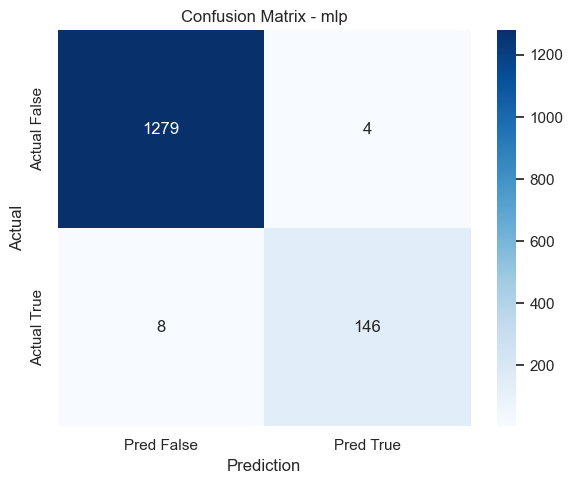

In [15]:
best_name = max(test_metrics, key=lambda name: (test_metrics[name]['mae'] <= 0.02, -test_metrics[name]['mae'], test_metrics[name]['f1'], test_metrics[name]['accuracy']))
best_metrics = test_metrics[best_name]
print('Best model:', best_name)
print(best_metrics)

confusion = np.array([[best_metrics['tn'], best_metrics['fp']], [best_metrics['fn'], best_metrics['tp']]], dtype=int)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred False', 'Pred True'], yticklabels=['Actual False', 'Actual True'])
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 8. Export Model Produksi

Cell ini menyimpan model terbaik ke `.keras`, export SavedModel, dan menyimpan metadata training.

In [16]:
best_model = trained_models[best_name]
keras_path = OUTPUT_DIR / 'behavior_best_model.keras'
saved_model_path = OUTPUT_DIR / 'behavior_saved_model'
metadata_path = OUTPUT_DIR / 'behavior_metadata.json'

best_model.save(keras_path)
if saved_model_path.exists():
    shutil.rmtree(saved_model_path)
if hasattr(best_model, 'export'):
    best_model.export(str(saved_model_path))
else:
    tf.saved_model.save(best_model, str(saved_model_path))

metadata = {
    'modelVersion': MODEL_VERSION,
    'bestModel': best_name,
    'target': 'spike',
    'metrics': test_metrics,
    'questThresholds': {'minimumAccuracy': 0.85, 'maximumMae': 0.02},
    'riskThresholds': {'low': 0.4, 'medium': 0.7},
    'budgetRule': {'Needs': 0.5, 'Wants': 0.3, 'Investment': 0.2},
    'notes': [
        'Model ini adalah Behavior Spike Detection, bukan overspending forecast bulanan.',
        'Dataset simulasi memiliki pola label yang kuat, sehingga performa harus dijelaskan dengan hati-hati.',
        'spending_level dan log_amount tidak dipakai untuk mengurangi risiko feature leakage.'
    ]
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print('Saved .keras:', keras_path)
print('Exported SavedModel:', saved_model_path)
print('Saved metadata:', metadata_path)

INFO:tensorflow:Assets written to: z:\Dicoding\sadar-finance\ai\models\behavior_saved_model\assets


INFO:tensorflow:Assets written to: z:\Dicoding\sadar-finance\ai\models\behavior_saved_model\assets


Saved artifact at 'z:\Dicoding\sadar-finance\ai\models\behavior_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['amount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='amount')], ['month', TensorSpec(shape=(None, 1), dtype=tf.float32, name='month')], ['day', TensorSpec(shape=(None, 1), dtype=tf.float32, name='day')], ['week', TensorSpec(shape=(None, 1), dtype=tf.float32, name='week')], ['is_weekend', TensorSpec(shape=(None, 1), dtype=tf.float32, name='is_weekend')], ['rolling_7d_spending', TensorSpec(shape=(None, 1), dtype=tf.float32, name='rolling_7d_spending')], ['transaction_count', TensorSpec(shape=(None, 1), dtype=tf.float32, name='transaction_count')], ['merchant', TensorSpec(shape=(None, 1), dtype=tf.string, name='merchant')], ['category_detail', TensorSpec(shape=(None, 1), dtype=tf.string, name='category_detail')], ['category_primary', TensorSpec(shape=(None, 1), dtype=tf.string, name='category_primary')], ['payme

## 9. Inference Sederhana

Fungsi inference di bawah berdiri sendiri di notebook. Tidak memakai file `.py` dari repo.

In [17]:
def parse_date(value):
    if not value:
        return pd.Timestamp.now().to_pydatetime()
    return pd.to_datetime(value).to_pydatetime()


def time_of_day(hour):
    if 5 <= hour < 11:
        return 'Pagi'
    if 11 <= hour < 15:
        return 'Siang'
    if 15 <= hour < 18:
        return 'Sore'
    return 'Malam'


def risk_from_probability(probability):
    if probability >= 0.7:
        return 'high'
    if probability >= 0.4:
        return 'medium'
    return 'low'


def build_features(payload):
    dt = parse_date(payload.get('date') or payload.get('transactionDate'))
    amount = float(payload.get('amount', 0) or 0)
    category_primary = payload.get('categoryPrimary') or payload.get('category_primary') or payload.get('categoryGroup') or 'Wants'
    return {
        'amount': amount,
        'month': float(dt.month),
        'day': float(dt.day),
        'week': float(dt.isocalendar().week),
        'is_weekend': 1.0 if dt.weekday() >= 5 else 0.0,
        'rolling_7d_spending': float(payload.get('rolling7dSpending') or payload.get('rolling_7d_spending') or amount),
        'transaction_count': float(payload.get('transactionCount') or payload.get('transaction_count') or 1),
        'merchant': str(payload.get('merchant') or 'unknown'),
        'category_detail': str(payload.get('categoryDetail') or payload.get('category_detail') or 'unknown'),
        'category_primary': str(category_primary),
        'payment_method': str(payload.get('paymentMethod') or payload.get('payment_method') or 'unknown'),
        'payment_media': str(payload.get('paymentMedia') or payload.get('payment_media') or 'unknown'),
        'day_of_week': dt.strftime('%A'),
        'time_of_day': time_of_day(dt.hour),
    }


def predict_behavior(payload, model=best_model):
    features = build_features(payload)
    model_input = {key: np.array([value], dtype=np.float32 if key in NUMERIC_FEATURES else object) for key, value in features.items()}
    probability = float(model(model_input, training=False).numpy().reshape(-1)[0])
    return {
        'spikeProbability': round(probability, 4),
        'predictedSpike': probability >= 0.5,
        'riskLevel': risk_from_probability(probability),
        'categoryPrimary': features['category_primary'],
        'modelName': best_name,
        'modelVersion': MODEL_VERSION,
    }


samples = [
    {'amount': 45000, 'date': '2024-12-29T09:00:00', 'merchant': 'Indomaret', 'categoryDetail': 'groceries', 'categoryPrimary': 'Needs', 'paymentMethod': 'QRIS', 'paymentMedia': 'Gopay'},
    {'amount': 1800000, 'date': '2024-12-29T20:00:00', 'merchant': 'Tokopedia', 'categoryDetail': 'shopping', 'categoryPrimary': 'Wants', 'paymentMethod': 'Credit Card', 'paymentMedia': 'BCA'},
]

display(pd.DataFrame([predict_behavior(sample) for sample in samples]))

,spikeProbability,predictedSpike,riskLevel,categoryPrimary,modelName,modelVersion
0,0.0014,False,low,Needs,mlp,behavior-spike-v1
1,1.0000,True,high,Wants,mlp,behavior-spike-v1


## 10. TensorBoard

Log TensorBoard tersimpan di folder `LOG_DIR`. Di Colab, jalankan:

```python
%load_ext tensorboard
%tensorboard --logdir /content/behavior_logs
```

Di lokal, jalankan dari terminal:

```bash
tensorboard --logdir ai/logs/behavior_spike
```

## 11. Verifikasi REST API Flask dan Generative AI

Side quest REST API dipenuhi oleh Flask endpoint `POST /behavior/predict` di `ai/app.py`. Cell ini memakai Flask test client agar endpoint bisa diverifikasi tanpa menjalankan server manual.

Fitur Generative AI tersedia di `ai/inference/behavior.py` melalui `google.generativeai` jika environment variable `GOOGLE_API_KEY` atau `GEMINI_API_KEY` tersedia. Jika key tidak tersedia, sistem memakai rekomendasi fallback rule-based agar API tetap stabil.


In [18]:
import os
import inspect

try:
    from app import app
    from inference import behavior as behavior_service

    client = app.test_client()
    health_response = client.get('/health')
    predict_response = client.post('/behavior/predict', json={
        'amount': 1800000,
        'date': '2024-12-29T20:00:00',
        'merchant': 'Tokopedia',
        'categoryDetail': 'shopping',
        'categoryPrimary': 'Wants',
        'paymentMethod': 'Credit Card',
        'paymentMedia': 'BCA',
    })

    genai_source = inspect.getsource(behavior_service._try_generate_ai_text)
    has_genai_integration = 'google.generativeai' in genai_source
    has_genai_key = bool(os.getenv('GOOGLE_API_KEY') or os.getenv('GEMINI_API_KEY'))

    print('Flask /health:', health_response.status_code, health_response.get_json())
    print('Flask /behavior/predict:', predict_response.status_code, predict_response.get_json())
    print('Generative AI integration available:', has_genai_integration)
    print('Generative AI API key configured in this runtime:', has_genai_key)
    if not has_genai_key:
        print('No API key detected, so recommendation uses the rule-based fallback path.')
except Exception as exc:
    print('REST/Generative AI verification skipped or failed:', exc)


Flask /health: 200 {'features': ['ocr', 'nlp_receipt_extraction', 'behavior_spike_prediction'], 'message': 'SADAR Finance AI service is running', 'success': True}
Flask /behavior/predict: 200 {'data': {'budgetBucket': {'name': 'Wants', 'recommendedAllocation': 0.3}, 'categoryPrimary': 'Wants', 'modelName': 'mlp', 'modelVersion': 'behavior-spike-v1', 'predictedSpike': True, 'recommendation': 'Transaksi ini berisiko tinggi dan masuk kategori Wants. Coba cek ulang apakah masih sesuai dengan batas 30% budget.', 'riskLevel': 'high', 'spikeProbability': 1.0}, 'success': True}
Generative AI integration available: True
Generative AI API key configured in this runtime: False
No API key detected, so recommendation uses the rule-based fallback path.


## 12. Kesimpulan

Notebook ini melatih ulang dua model behavior dari awal tanpa bergantung pada script `.py` repo:

- MLP sebagai baseline.
- Deep & Cross Network sebagai model interaction-aware.
- Custom `CrossFeatureLayer`.
- Custom `WeightedBinaryCrossentropy`.
- Custom `QuestMetricCallback`.
- Custom training loop dengan `tf.GradientTape`.
- Visualisasi EDA, training history, metric comparison, dan confusion matrix.
- Export `.keras` dan SavedModel.
- Inference sederhana.

Narasi laporan yang aman: model mendeteksi **behavior spike**, lalu outputnya dapat dipakai sebagai sinyal untuk alert agar user tidak overspending.